# Pregunta 3



## a) 

Cargamos los 3 dataframes y los ordenamos para que esten en el mismo formato.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pvlib as pv

# =============================================================================
# 1. CARGA DE LOS 3 ARCHIVOS CSV
# =============================================================================
# a) TMY Explorador Solar (Encabezado de metadatos: 41 lineas)
df_tmy_explorador = pd.read_csv('DatosSolaresTMY_ExploradorSolar.csv', skiprows=41)

# b) TMY PVGIS (Encabezado de metadatos: 17 lineas, 8760 horas correspondientes a 1 anio tipico)
df_tmy_pvgis = pd.read_csv('DatosSolaresTMY_PVGIS.csv', skiprows=17, nrows=8760)

# c) Serie Multianual Explorador Solar (Encabezado de metadatos: 41 lineas, 2004 a 2016 continuo)
df_multi_explorador = pd.read_csv('DatosSolares2004_2016_ExploradorSolar.csv', skiprows=41)

print(f"Filas leidas - TMY Explorador Solar:      {len(df_tmy_explorador):,}")
print(f"Filas leidas - TMY PVGIS:                 {len(df_tmy_pvgis):,}")
print(f"Filas leidas - Serie Multianual Explorador: {len(df_multi_explorador):,}")

Filas leidas - TMY Explorador Solar:      8,760
Filas leidas - TMY PVGIS:                 8,760
Filas leidas - Serie Multianual Explorador: 113,952


In [23]:
# =============================================================================
# 2. TRATAMIENTO DE LA VARIABLE TEMPORAL
# =============================================================================
# Conversion uniforme de la columna temporal a datetime64 en los 3 dataframes
df_tmy_explorador['fecha_hora'] = pd.to_datetime(df_tmy_explorador['Fecha/Hora'])
df_multi_explorador['fecha_hora'] = pd.to_datetime(df_multi_explorador['Fecha/Hora'])

# En PVGIS el formato viene como 'YYYYMMDD:HHMM' en UTC
df_tmy_pvgis['fecha_hora'] = pd.to_datetime(df_tmy_pvgis['time(UTC)'], format='%Y%m%d:%H%M')

# Opcional: Si se requiere convertir PVGIS a hora local de Chile (America/Santiago / UTC-4 / UTC-3):
df_tmy_pvgis['fecha_hora'] = df_tmy_pvgis['fecha_hora'].dt.tz_localize('UTC').dt.tz_convert('America/Santiago').dt.tz_localize(None)

# =============================================================================
# 3. HOMOLOGACION, FILTRADO Y ORDENAMIENTO DE VARIABLES
# =============================================================================
# Diccionario de renombramiento para Explorador Solar
rename_explorador = {
    'ghi': 'ghi',     # Radiacion Global Horizontal [W/m2]
    'dni': 'dni',     # Radiacion Directa Normal [W/m2]
    'difh': 'dhi',    # Radiacion Difusa Horizontal [W/m2]
    'temp': 'temp',   # Temperatura a 2 metros [deg C]
    'vel': 'vel'      # Velocidad de viento [m/s]
}

# Diccionario de renombramiento para PVGIS
rename_pvgis = {
    'G(h)': 'ghi',    # Radiacion Global Horizontal [W/m2]
    'Gb(n)': 'dni',   # Radiacion Directa Normal [W/m2]
    'Gd(h)': 'dhi',   # Radiacion Difusa Horizontal [W/m2]
    'T2m': 'temp',    # Temperatura a 2 metros [deg C]
    'WS10m': 'vel'    # Velocidad de viento a 10m [m/s]
}

# Aplicar renombramiento
df_tmy_explorador = df_tmy_explorador.rename(columns=rename_explorador)
df_multi_explorador = df_multi_explorador.rename(columns=rename_explorador)
df_tmy_pvgis = df_tmy_pvgis.rename(columns=rename_pvgis)

# Definicion estricta del orden y nombres de columnas comunes
columnas_comunes = ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']

# Filtrar y ordenar los 3 DataFrames exactamente con las mismas columnas
df_tmy_explorador = df_tmy_explorador[columnas_comunes].copy()
df_tmy_pvgis = df_tmy_pvgis[columnas_comunes].copy()
df_multi_explorador = df_multi_explorador[columnas_comunes].copy()

# =============================================================================
# 4. VALIDACION DE CONSISTENCIA
# =============================================================================
print("Columnas en TMY Explorador Solar:", df_tmy_explorador.columns.tolist())
print("Columnas en TMY PVGIS:           ", df_tmy_pvgis.columns.tolist())
print("Columnas en Serie Multianual:    ", df_multi_explorador.columns.tolist())

assert list(df_tmy_explorador.columns) == list(df_tmy_pvgis.columns) == list(df_multi_explorador.columns) == columnas_comunes, "Las columnas no coinciden!"
print("\n[OK] Los 3 DataFrames tienen exactamente las mismas columnas y el mismo orden!")

Columnas en TMY Explorador Solar: ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']
Columnas en TMY PVGIS:            ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']
Columnas en Serie Multianual:     ['fecha_hora', 'ghi', 'dni', 'dhi', 'temp', 'vel']

[OK] Los 3 DataFrames tienen exactamente las mismas columnas y el mismo orden!


In [24]:
# Verificacion de las primeras 5 filas de cada DataFrame
print("=== Primeras 5 filas: df_tmy_explorador ===")
display(df_tmy_explorador.head())

print("=== Primeras 5 filas: df_tmy_pvgis ===")
display(df_tmy_pvgis.head())

print("=== Primeras 5 filas: df_multi_explorador ===")
display(df_multi_explorador.head())

=== Primeras 5 filas: df_tmy_explorador ===


,fecha_hora,ghi,dni,dhi,temp,vel
0,2006-01-01 00:00:00,0.0,0.0,0.0,15.48,2.60
1,2006-01-01 01:00:00,0.0,0.0,0.0,14.72,2.89
2,2006-01-01 02:00:00,0.0,0.0,0.0,14.26,2.76
3,2006-01-01 03:00:00,0.0,0.0,0.0,13.23,2.57
4,2006-01-01 04:00:00,0.0,0.0,0.0,11.98,2.74


=== Primeras 5 filas: df_tmy_pvgis ===


,fecha_hora,ghi,dni,dhi,temp,vel
0,2016-12-31 21:00:00,0.0,-0.0,0.0,14.03,0.91
1,2016-12-31 22:00:00,0.0,-0.0,0.0,13.59,0.85
2,2016-12-31 23:00:00,0.0,-0.0,0.0,13.15,0.79
3,2017-01-01 00:00:00,0.0,-0.0,0.0,12.72,0.73
4,2017-01-01 01:00:00,0.0,-0.0,0.0,12.28,0.67


=== Primeras 5 filas: df_multi_explorador ===


,fecha_hora,ghi,dni,dhi,temp,vel
0,2004-01-01 00:00:00,0.0,0.0,0.0,16.54,2.47
1,2004-01-01 01:00:00,0.0,0.0,0.0,15.74,2.51
2,2004-01-01 02:00:00,0.0,0.0,0.0,15.30,2.12
3,2004-01-01 03:00:00,0.0,0.0,0.0,14.43,2.20
4,2004-01-01 04:00:00,0.0,0.0,0.0,13.22,2.54


Se crea en base a los dataframes, la tabla con los totales de GHI y DNI por fuente. Se considera la desviacion de los datos de PVGIS, respecto al explorador.

In [25]:
#formato temporal
for df in [df_tmy_explorador, df_tmy_pvgis, df_multi_explorador]:
    df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])
    df['año'] = df['fecha_hora'].dt.year
    df['mes'] = df['fecha_hora'].dt.month
    df['hora'] = df['fecha_hora'].dt.hour

# sumar los totales
ghi_exp = df_tmy_explorador['ghi'].sum() / 1000.0
dni_exp = df_tmy_explorador['dni'].sum() / 1000.0

ghi_pvgis = df_tmy_pvgis['ghi'].sum() / 1000.0
dni_pvgis = df_tmy_pvgis['dni'].sum() / 1000.0

# desviaciones relativas
eps_ghi = ((ghi_pvgis - ghi_exp) / ghi_exp) * 100.0
eps_dni = ((dni_pvgis - dni_exp) / dni_exp) * 100.0

#nueva tabla con los totales
df_tabla_totales = pd.DataFrame({
    'Variable': ['GHI [kWh/m²·año]', 'DNI [kWh/m²·año]'],
    'Explorador Solar': [ghi_exp, dni_exp],
    'PVGIS': [ghi_pvgis, dni_pvgis],
    'Desviación[%]': [eps_ghi, eps_dni]})

df_tabla_totales.head()

,Variable,Explorador Solar,PVGIS,Desviación[%]
0,GHI [kWh/m²·año],2129.4943,2303.79592,8.185118
1,DNI [kWh/m²·año],2416.2451,2766.67764,14.503187


Ahora, se consideran los totales mensuales de las 2 variables

In [26]:
mensual_exp = (df_tmy_explorador.groupby('mes')[['ghi', 'dni']].sum() / 1000.0)
mensual_pvgis = (df_tmy_pvgis.groupby('mes')[['ghi', 'dni']].sum() / 1000.0)

print(mensual_exp)
print(mensual_pvgis)

           ghi        dni
mes                      
1    283.05198  346.16237
2    230.87454  283.57244
3    208.98062  260.13114
4    143.00052  181.37408
5     94.42386  104.85857
6     69.13014   63.94526
7     69.79654   51.59146
8    105.49444   97.21549
9    161.07756  174.77870
10   223.16384  247.99905
11   258.42346  296.31323
12   282.07680  308.30331
           ghi        dni
mes                      
1    271.17734  305.00860
2    206.80699  220.54711
3    216.37601  265.11741
4    164.45040  228.53283
5    129.25795  202.55832
6     97.52361  139.62626
7    121.84590  168.51512
8    160.75313  222.69600
9    169.12703  176.81318
10   234.06621  259.70703
11   262.18396  287.68354
12   270.22739  289.87224


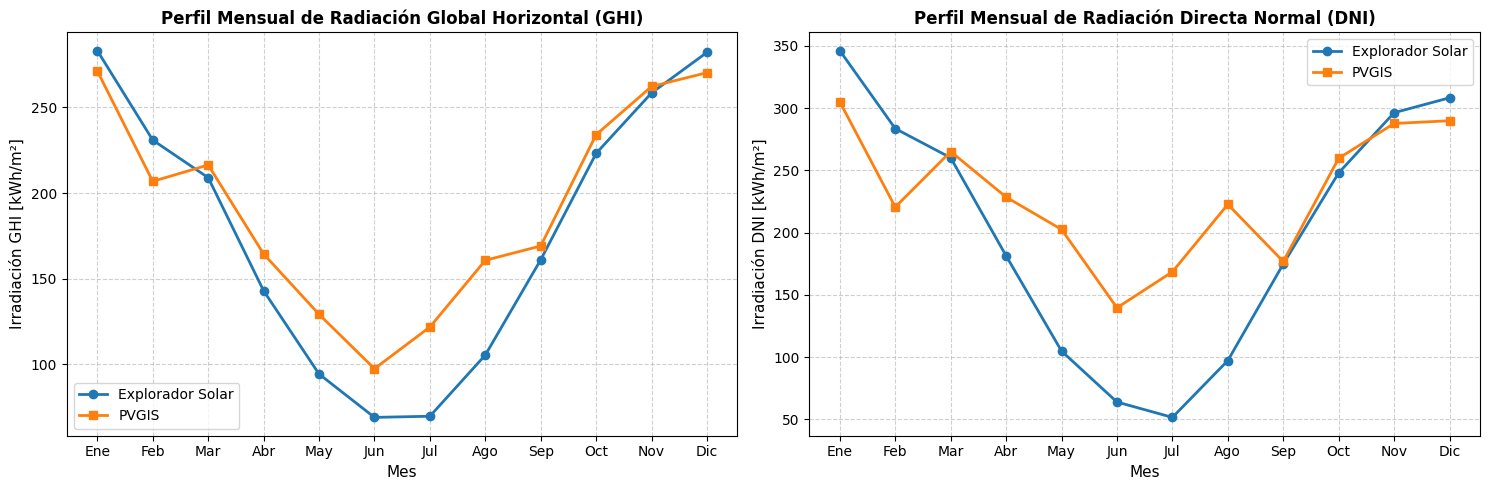

In [27]:
# =============================================================================
# PERFILES MENSUALES DE GHI Y DNI: EXPLORADOR SOLAR VS. PVGIS
# =============================================================================
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Crear figura con 2 graficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Grafico 1: Perfil Mensual de GHI ---
axes[0].plot(mensual_exp.index, mensual_exp['ghi'], marker='o', linewidth=2, color='#1f77b4', label='Explorador Solar')
axes[0].plot(mensual_pvgis.index, mensual_pvgis['ghi'], marker='s', linewidth=2, color='#ff7f0e', label='PVGIS')
axes[0].set_title('Perfil Mensual de Radiación Global Horizontal (GHI)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Irradiación GHI [kWh/m²]', fontsize=11)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# --- Grafico 2: Perfil Mensual de DNI ---
axes[1].plot(mensual_exp.index, mensual_exp['dni'], marker='o', linewidth=2, color='#1f77b4', label='Explorador Solar')
axes[1].plot(mensual_pvgis.index, mensual_pvgis['dni'], marker='s', linewidth=2, color='#ff7f0e', label='PVGIS')
axes[1].set_title('Perfil Mensual de Radiación Directa Normal (DNI)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Irradiación DNI [kWh/m²]', fontsize=11)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Luego, se grafica el mapa de calor, donde se compara la disponibilidad energetica por hora x mes, de la diferencia entre ambas fuentes

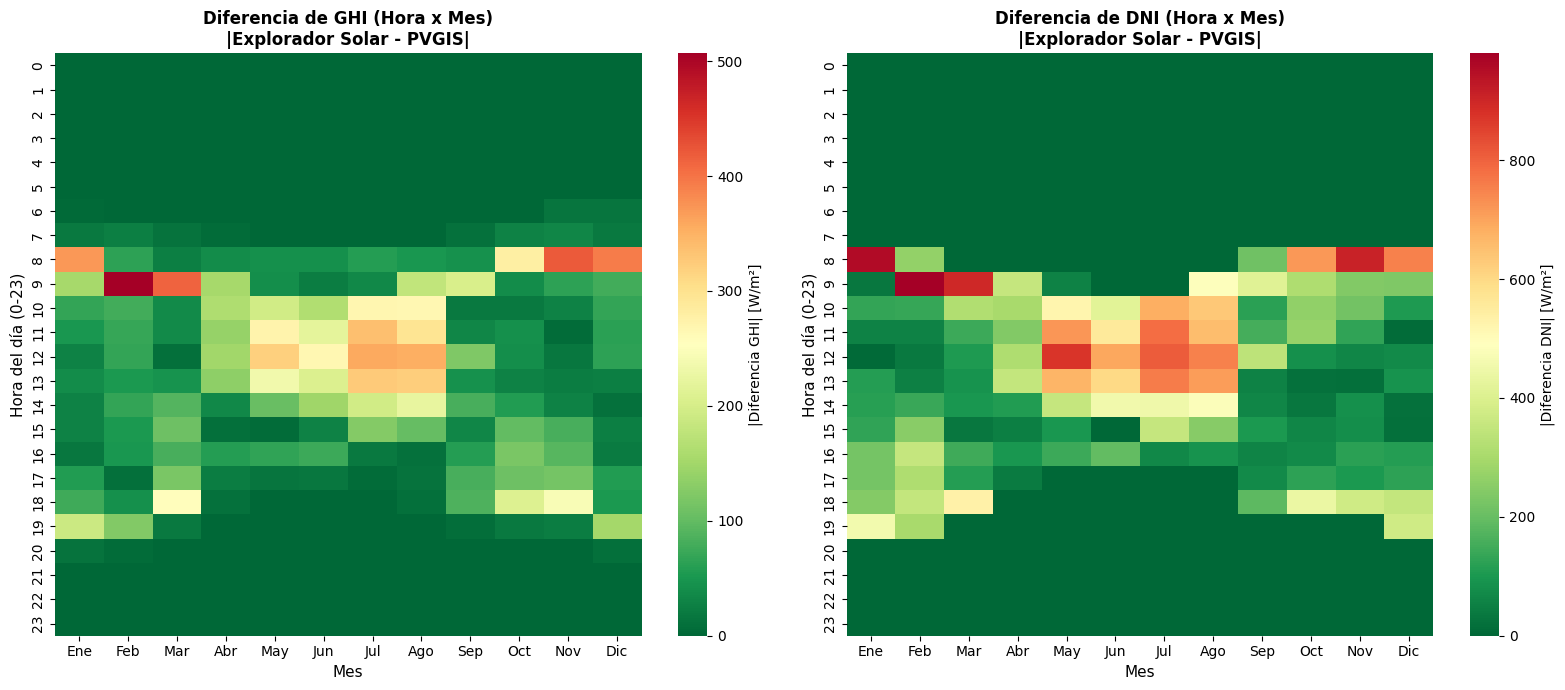

In [28]:
# =============================================================================
# 1. CREACION DE MALLAS 24 x 12 (PROMEDIO HORA x MES)
# =============================================================================
# Mallas para GHI (24 horas x 12 meses)
malla_ghi_exp = df_tmy_explorador.pivot_table(index='hora', columns='mes', values='ghi', aggfunc='mean')
malla_ghi_pvgis = df_tmy_pvgis.pivot_table(index='hora', columns='mes', values='ghi', aggfunc='mean')

# Mallas para DNI (24 horas x 12 meses)
malla_dni_exp = df_tmy_explorador.pivot_table(index='hora', columns='mes', values='dni', aggfunc='mean')
malla_dni_pvgis = df_tmy_pvgis.pivot_table(index='hora', columns='mes', values='dni', aggfunc='mean')

# =============================================================================
# 2. RESTA DE MALLAS (MAGNITUD DE LA DIFERENCIA)
# =============================================================================
# Se calcula el valor absoluto de la resta para que las mayores diferencias correspondan al rojo (extremo superior de la paleta)
diff_ghi = (malla_ghi_exp - malla_ghi_pvgis).abs()
diff_dni = (malla_dni_exp - malla_dni_pvgis).abs()

# =============================================================================
# 3. GRAFICO DE MAPAS DE CALOR CON SEABORN (PALETA VERDE A ROJO)
# =============================================================================
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Mapa de Calor: GHI ---
sns.heatmap(diff_ghi, ax=axes[0], cmap='RdYlGn_r', xticklabels=meses, yticklabels=True,
            cbar_kws={'label': '|Diferencia GHI| [W/m²]'})
axes[0].set_title('Diferencia de GHI (Hora x Mes)\n|Explorador Solar - PVGIS|', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Hora del día (0-23)', fontsize=11)

# --- Mapa de Calor: DNI ---
sns.heatmap(diff_dni, ax=axes[1], cmap='RdYlGn_r', xticklabels=meses, yticklabels=True,
            cbar_kws={'label': '|Diferencia DNI| [W/m²]'})
axes[1].set_title('Diferencia de DNI (Hora x Mes)\n|Explorador Solar - PVGIS|', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Hora del día (0-23)', fontsize=11)

plt.tight_layout()
plt.show()

## b)

Ahora interesa comparar, ocupando la base de datos de la serie multianual de REcurso SOlar, la variabilidad y diferencias que hay en la radiación reportada año a año. Para ello, se realiza una tabla con las medias de GHI de todos los años en la serie

In [29]:
df_multi_explorador.head()

,fecha_hora,ghi,dni,dhi,temp,vel,año,mes,hora
0,2004-01-01 00:00:00,0.0,0.0,0.0,16.54,2.47,2004,1,0
1,2004-01-01 01:00:00,0.0,0.0,0.0,15.74,2.51,2004,1,1
2,2004-01-01 02:00:00,0.0,0.0,0.0,15.30,2.12,2004,1,2
3,2004-01-01 03:00:00,0.0,0.0,0.0,14.43,2.20,2004,1,3
4,2004-01-01 04:00:00,0.0,0.0,0.0,13.22,2.54,2004,1,4


In [30]:
anual_multi = df_multi_explorador.groupby('año')[['ghi','dni']].sum()/1000

definiendo una funcion para calcular las metricas estadisticas

In [31]:
def calcular_metricas(serie, nombre_var):
    p50 = serie.mean()
    sigma = serie.std(ddof=1)
    cv = sigma / p50
    mejor_año_val = serie.max()
    mejor_año_num = serie.idxmax()
    peor_año_val = serie.min()
    peor_año_num = serie.idxmin()
    p90 = p50 - 1.28 * sigma
    
    return {
        'Variable': nombre_var,
        'P50 [kWh/m2 x año]': p50,
        'Desv. Estándar [kWh/m2 x año]': sigma,
        'CV  [%]': cv * 100,
        'Mejor Año': f"{mejor_año_val:.2f} ({mejor_año_num})",
        'Peor Año': f"{peor_año_val:.2f} ({peor_año_num})",
        'P90 [kWh/m2 x año]': p90
    }

In [32]:
estad_ghi = calcular_metricas(anual_multi['ghi'],'ghi')
estad_dni = calcular_metricas(anual_multi['dni'],'dni')

df_estad = pd.DataFrame([estad_ghi,estad_dni])
df_estad.head()

,Variable,P50 [kWh/m2 x año],Desv. Estándar [kWh/m2 x año],CV [%],Mejor Año,Peor Año,P90 [kWh/m2 x año]
0,ghi,2142.640323,104.18191,4.862314,2339.52 (2010),1986.33 (2016),2009.287478
1,dni,2498.908835,276.30517,11.057033,3008.33 (2010),2105.82 (2015),2145.238218


Graficando los resultados

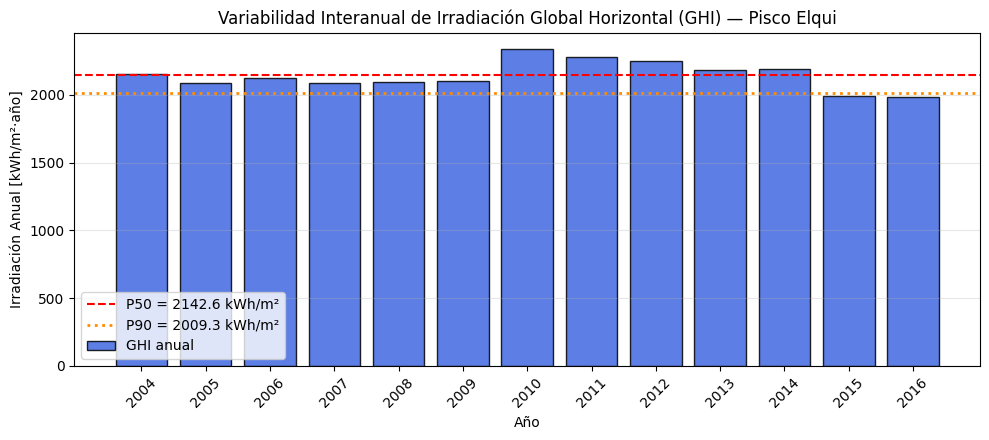

In [33]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(anual_multi.index, anual_multi['ghi'], color='royalblue', alpha=0.85, edgecolor='black', label='GHI anual')
ax.axhline(estad_ghi['P50 [kWh/m2 x año]'], color='red', linestyle='--', linewidth=1.5, label=f"P50 = {estad_ghi['P50 [kWh/m2 x año]']:.1f} kWh/m²")
ax.axhline(estad_ghi['P90 [kWh/m2 x año]'], color='darkorange', linestyle=':', linewidth=2, label=f"P90 = {estad_ghi['P90 [kWh/m2 x año]']:.1f} kWh/m²")

ax.set_title('Variabilidad Interanual de Irradiación Global Horizontal (GHI) — Pisco Elqui')
ax.set_xlabel('Año')
ax.set_ylabel('Irradiación Anual [kWh/m²·año]')
ax.set_xticks(anual_multi.index)
ax.set_xticklabels(anual_multi.index, rotation=45)
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## c)